<a href="https://colab.research.google.com/github/doney25/CaseStudy/blob/main/Pre_Processing_Case_Study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [327]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [328]:
data=pd.read_csv('/content/House_Pricing.csv')
data

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,...,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,7129300520,14 October 2017,221900.0,3,1.00,1180.0,5650.0,1.0,No,NaN,...,7,1180.0,0,63,0,98178.0,47.5112,-122.257,1340.0,5650
1,6414100192,14 December 2017,538000.0,3,2.25,2570.0,7242.0,2.0,No,NaN,...,7,2170.0,400,67,1991,98125.0,47.7210,-122.319,1690.0,7639
2,5631500400,15 February 2016,180000.0,2,1.00,770.0,10000.0,1.0,No,NaN,...,6,770.0,0,85,0,98028.0,47.7379,-122.233,2720.0,8062
3,2487200875,14 December 2017,604000.0,4,3.00,1960.0,5000.0,1.0,No,NaN,...,7,1050.0,910,53,0,98136.0,47.5208,-122.393,1360.0,5000
4,1954400510,15 February 2016,510000.0,3,2.00,1680.0,8080.0,1.0,No,NaN,...,8,1680.0,0,31,0,98074.0,47.6168,-122.045,1800.0,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,14 May 2017,360000.0,3,2.50,1530.0,1131.0,3.0,No,NaN,...,8,1530.0,0,9,0,98103.0,47.6993,-122.346,1530.0,1509
21609,6600060120,15 February 2016,400000.0,4,2.50,2310.0,5813.0,2.0,No,NaN,...,8,2310.0,0,4,0,98146.0,47.5107,-122.362,1830.0,7200
21610,1523300141,14 June 2017,402101.0,2,0.75,1020.0,1350.0,2.0,No,NaN,...,7,1020.0,0,9,0,98144.0,47.5944,-122.299,1020.0,2007
21611,291310100,15 January 2016,400000.0,3,2.50,1600.0,2388.0,2.0,No,NaN,...,8,1600.0,0,14,0,98027.0,47.5345,-122.069,1410.0,1287


In [329]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   ID                                         21613 non-null  int64  
 1   Date House was Sold                        21613 non-null  object 
 2   Sale Price                                 21609 non-null  float64
 3   No of Bedrooms                             21613 non-null  int64  
 4   No of Bathrooms                            21609 non-null  float64
 5   Flat Area (in Sqft)                        21604 non-null  float64
 6   Lot Area (in Sqft)                         21604 non-null  float64
 7   No of Floors                               21613 non-null  float64
 8   Waterfront View                            21613 non-null  object 
 9   No of Times Visited                        2124 non-null   object 
 10  Condition of the House

In [330]:
data.describe()

,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
count,2.161300e+04,2.160900e+04,21613.000000,21609.000000,21604.000000,2.160400e+04,21613.000000,21613.000000,21610.000000,21613.000000,21613.000000,21613.000000,21612.000000,21612.000000,21612.000000,21612.000000,21613.000000
mean,4.580302e+09,5.401984e+05,3.370842,2.114732,2079.931772,1.510776e+04,1.494309,7.623467,1788.344193,291.509045,46.994864,84.402258,98077.937766,47.560048,-122.213892,1986.538914,12768.455652
std,2.876566e+09,3.673890e+05,0.930062,0.770138,918.487597,4.142827e+04,0.539989,1.105439,827.982604,442.575043,29.373411,401.679240,53.505425,0.138565,0.140830,685.404255,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,1.000000,290.000000,0.000000,3.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1429.250000,5.040000e+03,1.000000,7.000000,1190.000000,0.000000,21.000000,0.000000,98033.000000,47.470975,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.617500e+03,1.500000,7.000000,1560.000000,0.000000,43.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068825e+04,2.000000,8.000000,2210.000000,560.000000,67.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,10.000000,9410.000000,4820.000000,118.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [331]:
data=data.drop_duplicates()
print("Duplicate rows removed")

Duplicate rows removed


In [332]:
data.isna().sum()

,0
ID,0
Date House was Sold,0
Sale Price,4
No of Bedrooms,0
No of Bathrooms,4
Flat Area (in Sqft),9
Lot Area (in Sqft),9
No of Floors,0
Waterfront View,0
No of Times Visited,19489


In [333]:
data['Date House was Sold']=pd.to_datetime(data['Date House was Sold'])

#Handling Missing Values

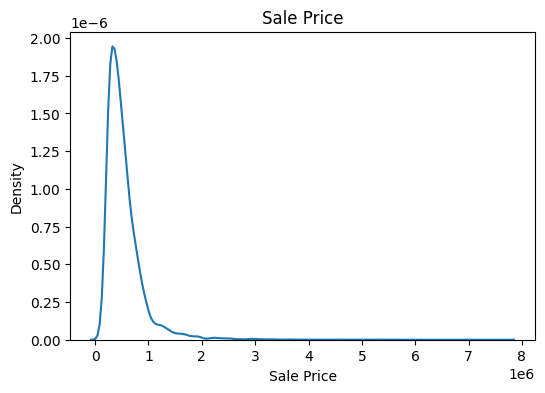

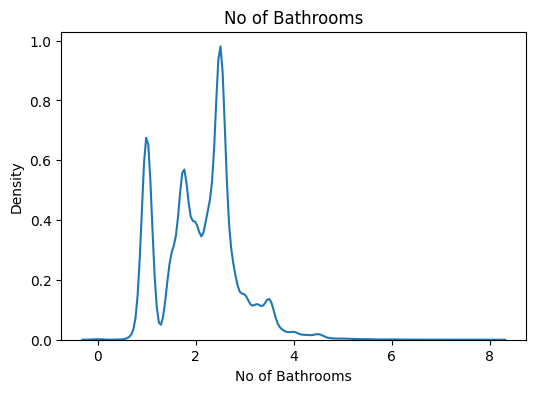

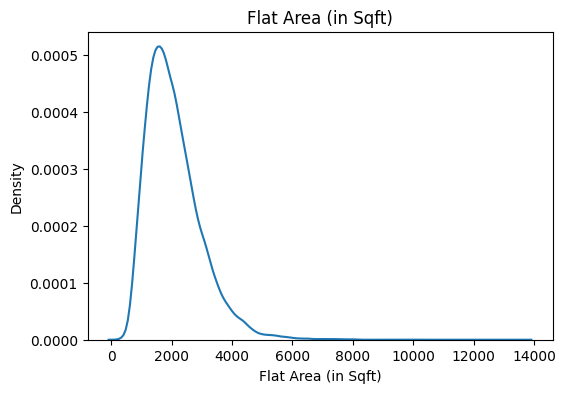

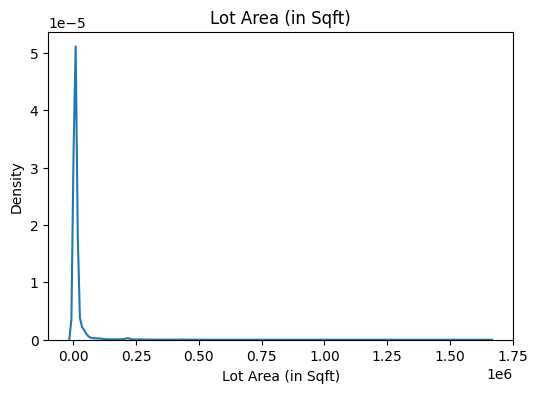

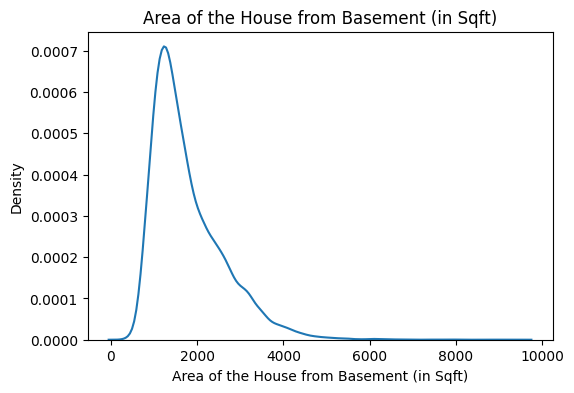

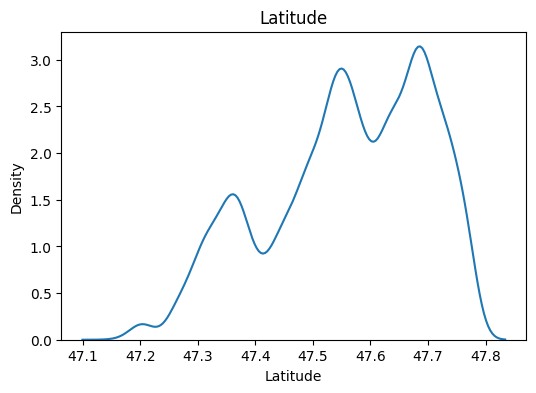

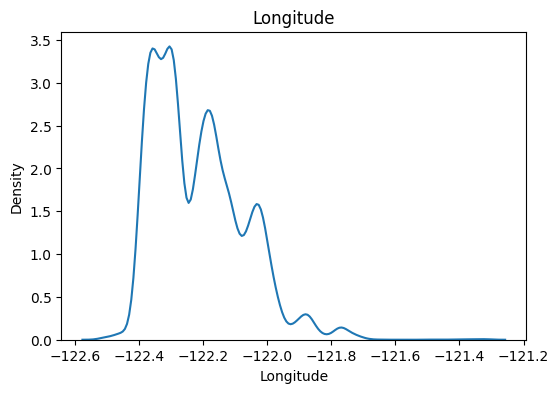

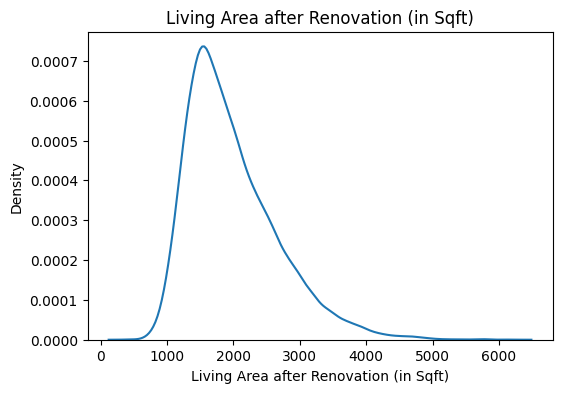

In [334]:
numerical_columns = ['Sale Price','No of Bathrooms','Flat Area (in Sqft)','Lot Area (in Sqft)','Area of the House from Basement (in Sqft)',
                     'Latitude','Longitude','Living Area after Renovation (in Sqft)' ]
for i in numerical_columns:
  plt.figure(figsize=(6,4))
  sns.kdeplot(data=data, x=i)
  plt.title(i)

In [335]:
skewness = data[numerical_columns].skew()
for col in numerical_columns:
    print(f"{col:45} {skewness[col]:.3f}")

Sale Price                                    4.021
No of Bathrooms                               0.511
Flat Area (in Sqft)                           1.472
Lot Area (in Sqft)                            13.058
Area of the House from Basement (in Sqft)     1.447
Latitude                                      -0.485
Longitude                                     0.885
Living Area after Renovation (in Sqft)        1.108


In [336]:
for i in numerical_columns:
  data[i]=data[i].fillna(data[i].median())

In [337]:
data['Zipcode']=data['Zipcode'].fillna(data['Zipcode'].mode()[0])

In [338]:
data['No of Times Visited']=data['No of Times Visited'].fillna('Zero')

In [339]:
data.isna().sum()

,0
ID,0
Date House was Sold,0
Sale Price,0
No of Bedrooms,0
No of Bathrooms,0
Flat Area (in Sqft),0
Lot Area (in Sqft),0
No of Floors,0
Waterfront View,0
No of Times Visited,0


In [340]:
data["No of Bathrooms"] = data["No of Bathrooms"].astype(int)
data['No of Floors']=data['No of Floors'].astype(int)

#Scaling

In [341]:
numerical_columns.remove('Sale Price')
numerical_columns.remove('No of Bathrooms')

In [342]:
from sklearn.preprocessing import MinMaxScaler

In [343]:
minmax=MinMaxScaler()
data[numerical_columns]=minmax.fit_transform(data[numerical_columns])
print("Numerical Values are scaled.")

Numerical Values are scaled.


#Encoding

In [344]:
from sklearn.preprocessing import LabelEncoder,OrdinalEncoder

In [345]:
print(data['No of Times Visited'].unique())
print(data['Condition of the House'].unique())

['Zero' 'Thrice' 'Four' 'Twice' 'Once']
['Fair' 'Excellent' 'Good' 'Bad' 'Okay']


In [346]:
label=LabelEncoder()

data['Waterfront View']=label.fit_transform(data['Waterfront View'])
data['No of Times Visited']=data['No of Times Visited'].map({'Zero':0, 'Thrice':3, 'Four':4, 'Twice':2, 'Once':1})
data['Condition of the House']=data['Condition of the House'].map({'Okay':1,'Bad':0,'Good':3,'Excellent':4,'Fair':2})

In [347]:
data=data.drop(columns= ['ID','Overall Grade','Area of the House from Basement (in Sqft)','Basement Area (in Sqft)'])

In [348]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 17 columns):
 #   Column                                  Non-Null Count  Dtype         
---  ------                                  --------------  -----         
 0   Date House was Sold                     21613 non-null  datetime64[ns]
 1   Sale Price                              21613 non-null  float64       
 2   No of Bedrooms                          21613 non-null  int64         
 3   No of Bathrooms                         21613 non-null  int64         
 4   Flat Area (in Sqft)                     21613 non-null  float64       
 5   Lot Area (in Sqft)                      21613 non-null  float64       
 6   No of Floors                            21613 non-null  int64         
 7   Waterfront View                         21613 non-null  int64         
 8   No of Times Visited                     21613 non-null  int64         
 9   Condition of the House                  21613 non-

#Outlier Removal

In [349]:
col=data.select_dtypes(include=[np.number]).columns

In [350]:
col=col.drop(['Sale Price'])

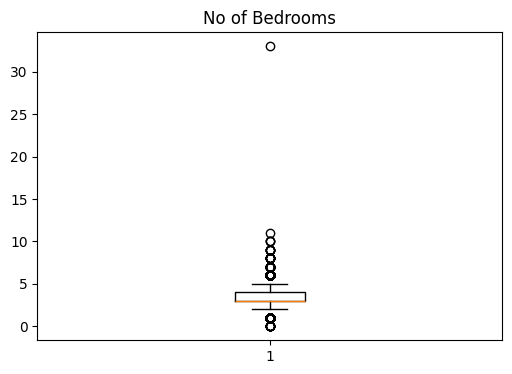

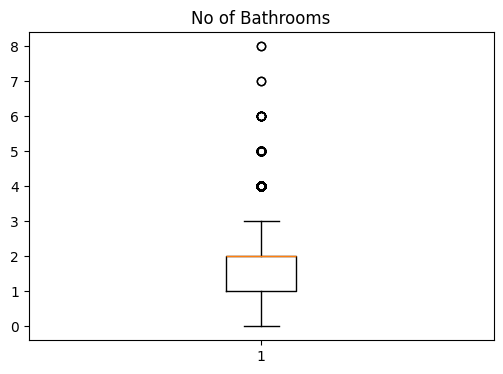

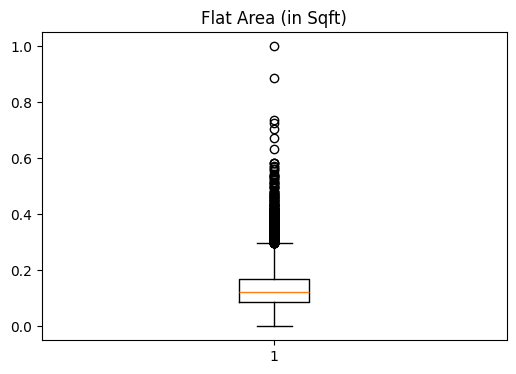

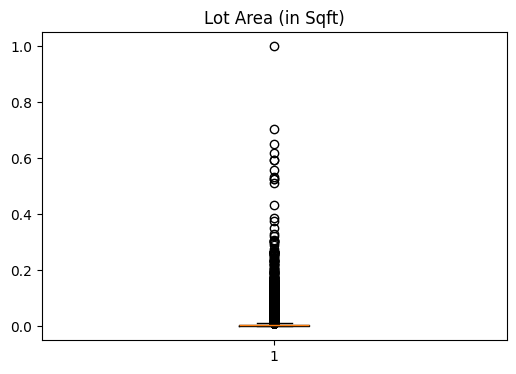

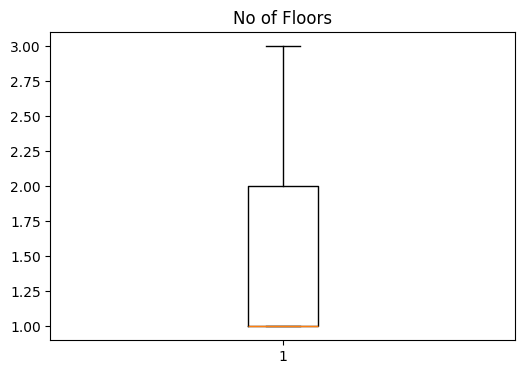

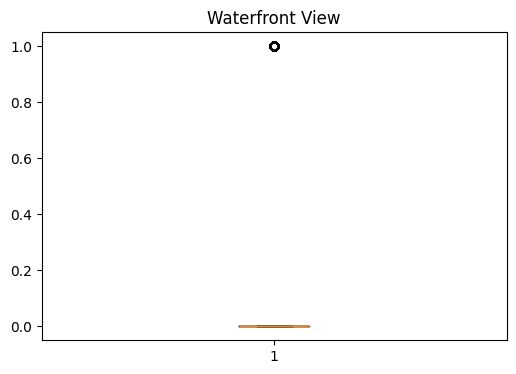

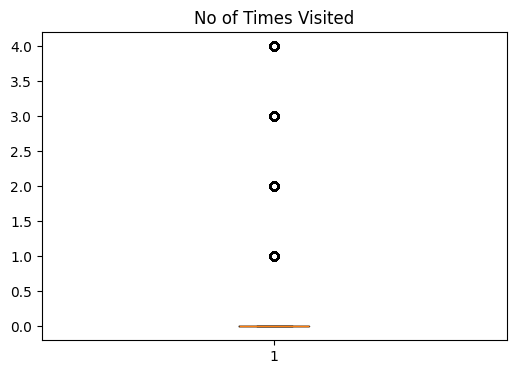

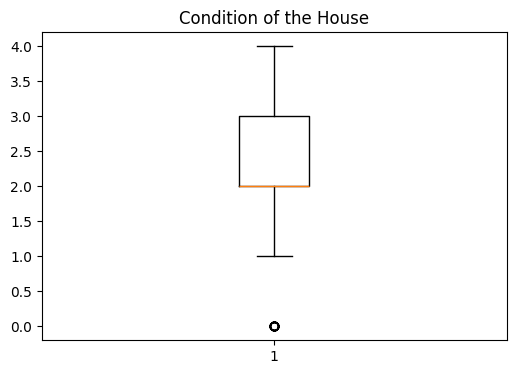

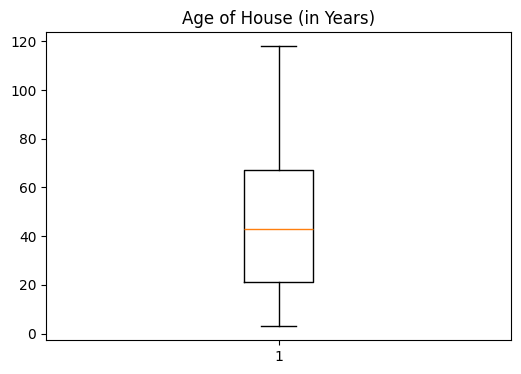

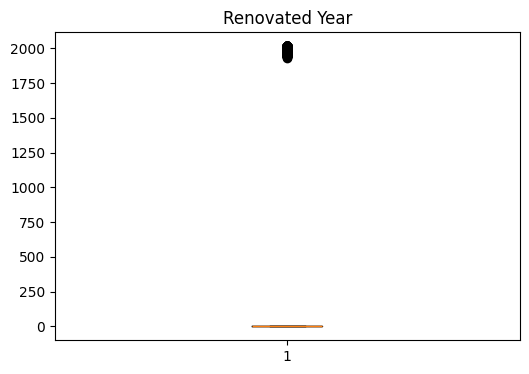

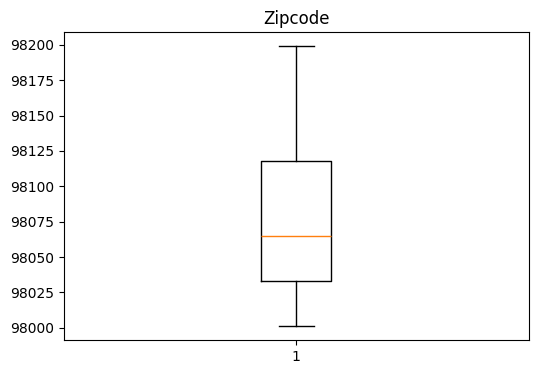

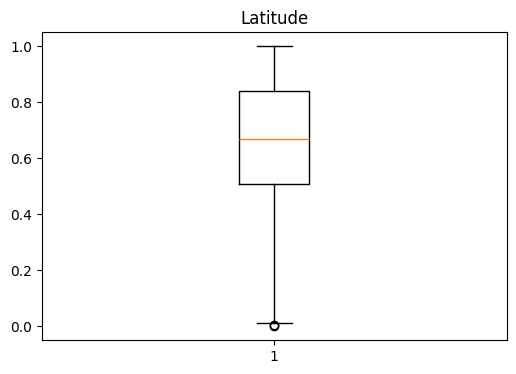

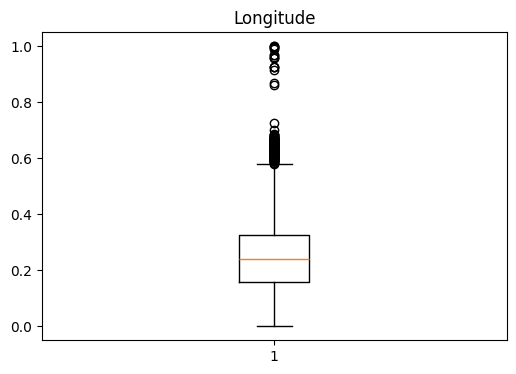

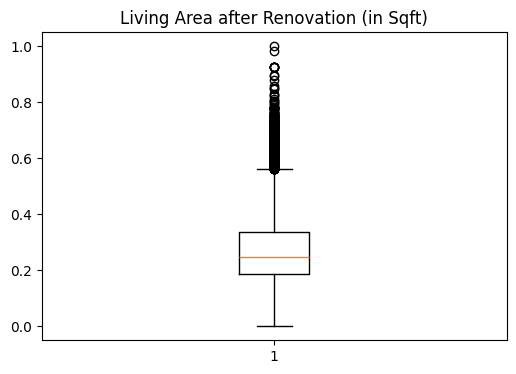

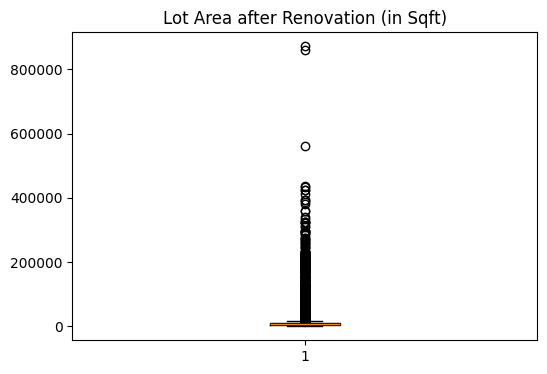

In [351]:
for i in col:
  plt.figure(figsize=(6,4))
  plt.boxplot(data=data, x=i)
  plt.title(i)

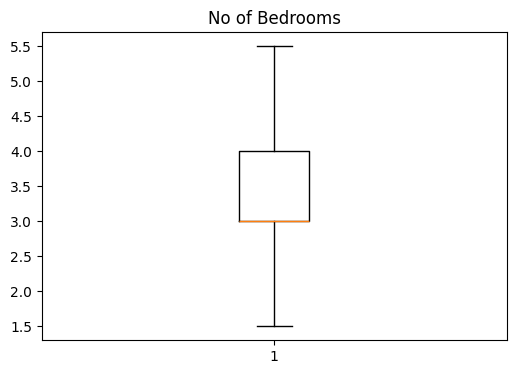

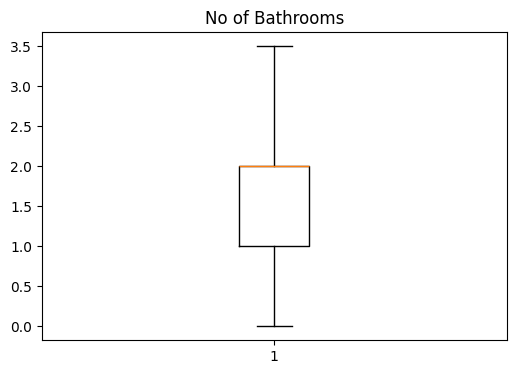

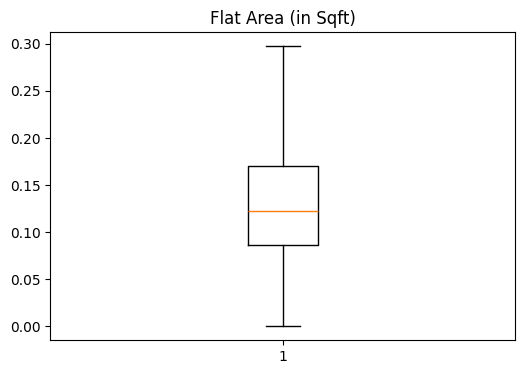

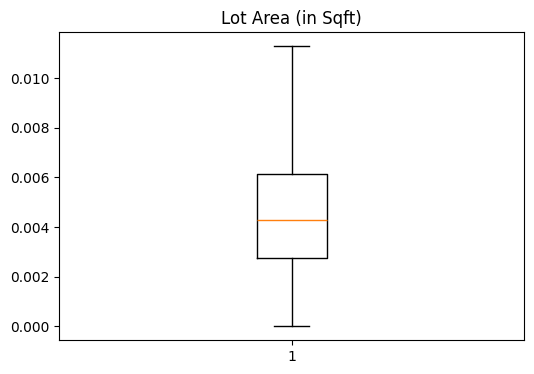

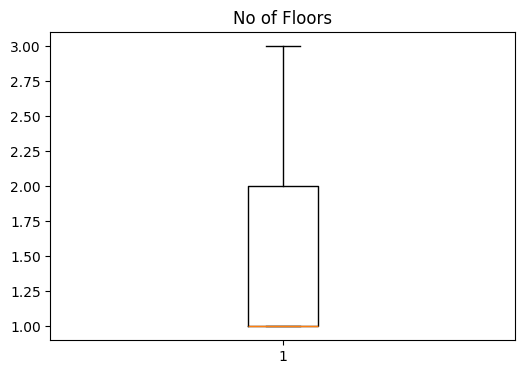

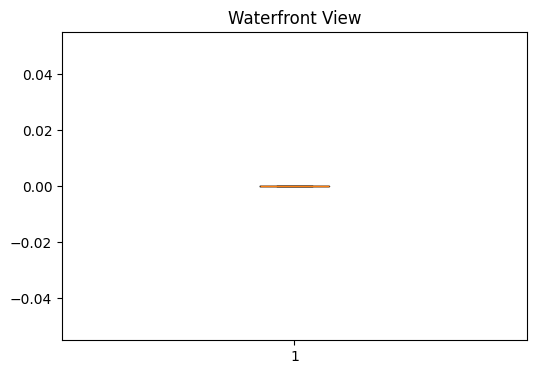

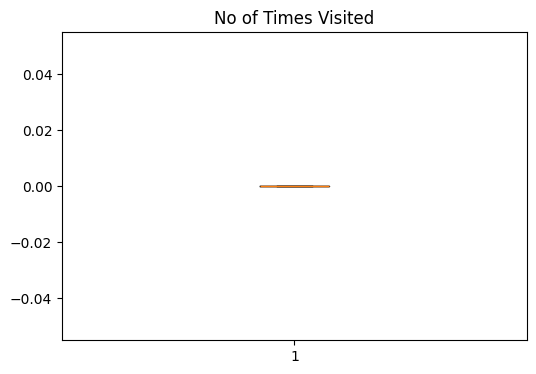

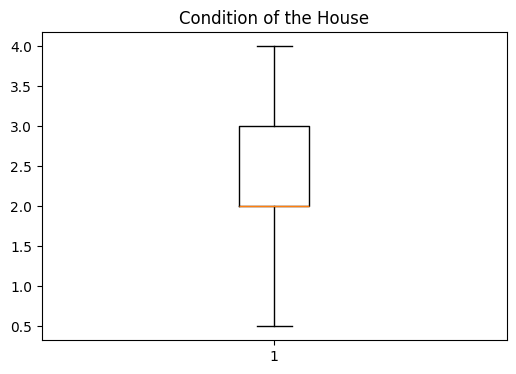

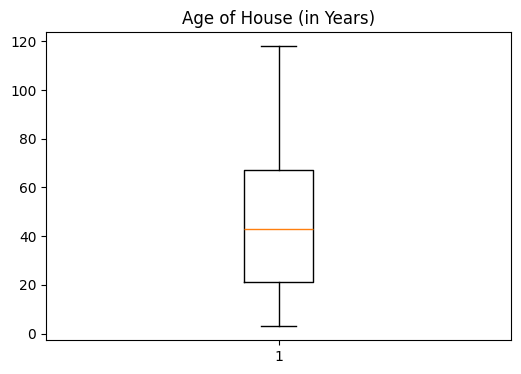

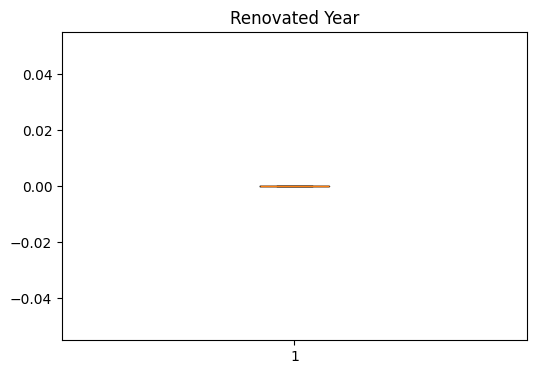

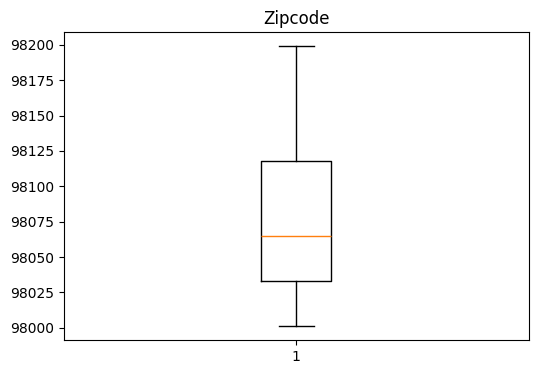

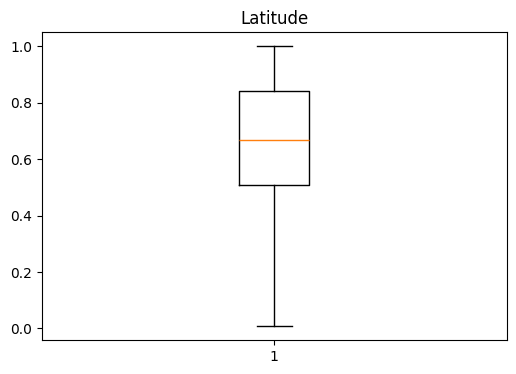

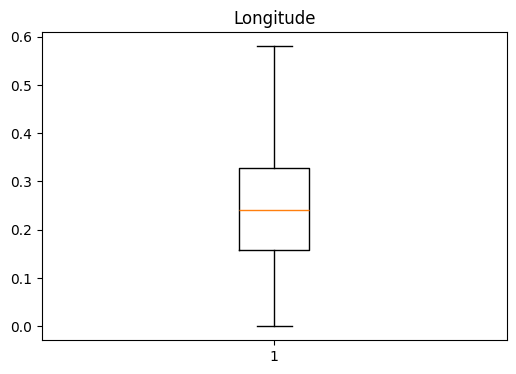

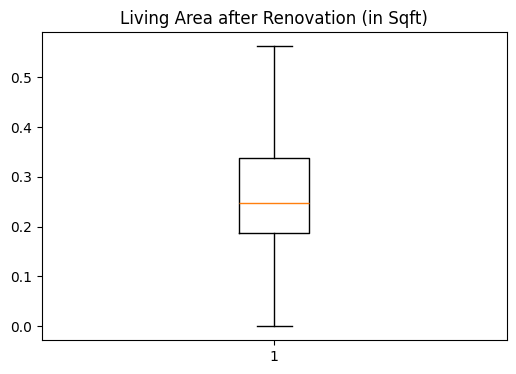

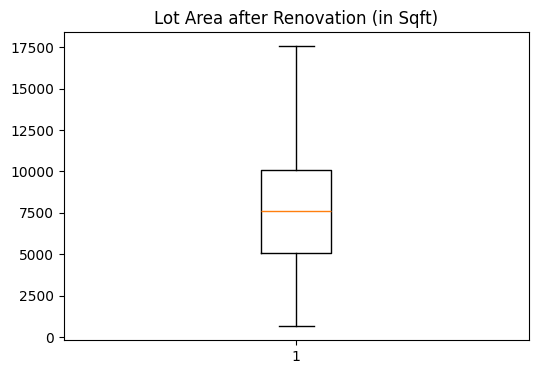

In [352]:
for i in col:
  q1=data[i].quantile(0.25)
  q3=data[i].quantile(0.75)
  IQR=q3-q1
  lower_bound=q1-1.5*IQR
  upper_bound=q3+1.5*IQR

  data[i]=data[i].clip(lower=lower_bound,upper=upper_bound)
  plt.figure(figsize=(6,4))
  plt.boxplot(data=data, x=i)
  plt.title(i)

#Testing

In [353]:
y=data['Sale Price']
x=data.drop(columns='Sale Price')

In [354]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [355]:
print("\nTraining Features :", x_train.shape)
print("Testing Features  :", x_test.shape)
print("Training Target   :", y_train.shape)
print("Testing Target    :", y_test.shape)


Training Features : (17290, 16)
Testing Features  : (4323, 16)
Training Target   : (17290,)
Testing Target    : (4323,)
